# Freshwater flux from the Greenland ice sheet - a tool for hydropower planning

This notebook is a demonstrator from the **Digital Twin Component for Ice Sheets (DTC-IS)**, an ESA-funded, EO-driven digital twin project.

DTC Ice Sheets integrates Earth Observation, in-situ data, reanalysis products, and advanced data-driven models to provide a dynamic and science-based representation of the Greenland and Antarctic ice sheets, including their ice shelves. It supports the monitoring, understanding, and prediction of ice-sheet change, delivering actionable information for research, policy, and scenario-based exploration.

· [Project Website](https://dtc-ice-sheets.org/) · [Interactive Dashboard](https://dashboards.dtc-ice-sheets.org/) · [Query API](https://query.dtc-ice-sheets.org)

---

Hydropower is at the heart of Greenland's energy system, providing most of its electricity and supporting the country's renewable energy ambitions. Greenland's many natural lakes act as dependable reservoirs, refilled each year by meltwater from the ice sheet. As the climate warms, this recharge is accelerating, offering opportunities for clean energy growth and even future power exports.

This interactive notebook predicts future proglacial discharge from the Greenland ice sheet using two generic digital twin modules - **Gaussian Random Field (GRF)** and **Functional Time Series (FTS)**. The GRF module combines heterogeneous datasets relevant for proglacial discharge prediction into a homogeneous datacube. The FTS module then uses statistical modelling to derive a predictive relationship between these data and observations of proglacial discharge. This tool then uses this relationship to forecast proglacial discharge into the future. These results can then be used by hydropower planners, to calculate hydropower potential.

**Key features:**
- **Choose model dependencies:** Do you want to include transient meltwater storage in supraglacial lakes, for example?
- **Flexible time period:** Specify the future period you are interested in.
- **Scenario exploration:** Choose your future scenario, and your future model forcing.
- **Visualization:** Instantly view predicted proglacial discharge totals and seasonal varaibility.

## How to use this notebook:
Step-by-step guidance is provided for each section. See sections with **USER INPUT** tag

**Requirements:**  
- This notebook is designed for use in Jupyter (or VS Code with the Jupyter extension). If using the notebook through Google Colab, Jupyter and python installations are not required.
- No prior coding experience is required; all interactions are via user-friendly widgets.

*For more details on the datasets and methods, see the documentation or code comments below.*

In [20]:
# Import required packages

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

In [21]:
# Year lengths in days from a given start year - used to ensure daily values are aligned correctly

year_days_2006 = [365, 365, 366, 365, 365, 365, 366, 365, 365, 365, 366, 365, 365, 365, 366, 365, 365, 365, 366, 365]
year_days_2015 = [365, 366, 365, 365, 365, 366, 365, 365, 365, 366, 365]

## Data provision

This notebook uses data which has been preprocessed and uploaded to be accessed by the DTC-IS API. Users are not required to make input data selections. Visualisations of the input data are provided below.

### Catchment selection

This section will allow you to a) select a predefined catchment or b) to select a proglacial outlet for which the catchment will be defined dynamically. This demonstrator draws on the Watson River basin, which has been demonstrated to be a suitable analog for the Tasersiaq Lake catchment, a major prospective site for hydropower development in Greenland.

<Axes: xlabel='metres easting', ylabel='metres northing'>

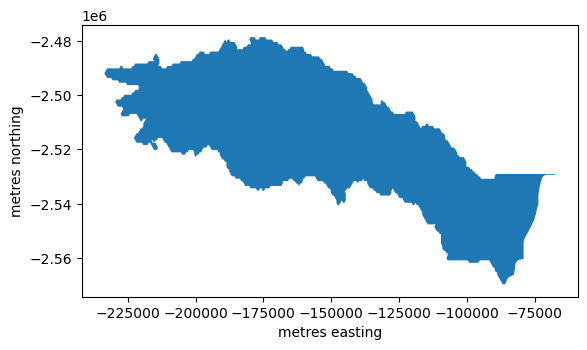

In [80]:
basin_shapefile = "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/SurfaceBasin.shp"
basin_shape = gpd.read_file(basin_shapefile)
fig, ax = plt.subplots(1, 1)
ax.set_xlabel("metres easting")
ax.set_ylabel("metres northing")
gpd.GeoSeries(basin_shape.geometry[2]).plot(ax=ax)

### Input dataset 1: surface lake intensity

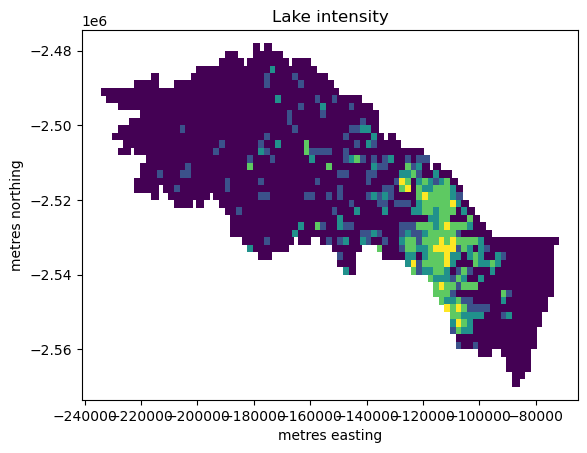

In [ ]:
locs = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/2014_Aug_centroid_logarea.csv",
    header=None,
).to_numpy()
vals = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/2014_Aug_logarea.csv", header=None
).to_numpy()
fig, ax = plt.subplots(1, 1)
# fig.set_size_inches(5,3)
# ax.set_xlim(xlim[0],xlim[1])
# ax.set_ylim(ylim[0],ylim[1])
ax.set_xlabel("metres easting")
ax.set_ylabel("metres northing")
ax.set_title("Lake intensity")
ax.scatter(locs[:, 0], locs[:, 1], c=vals, marker="s", linewidths=0, s=30)

### Input dataset: RACMO surface runoff

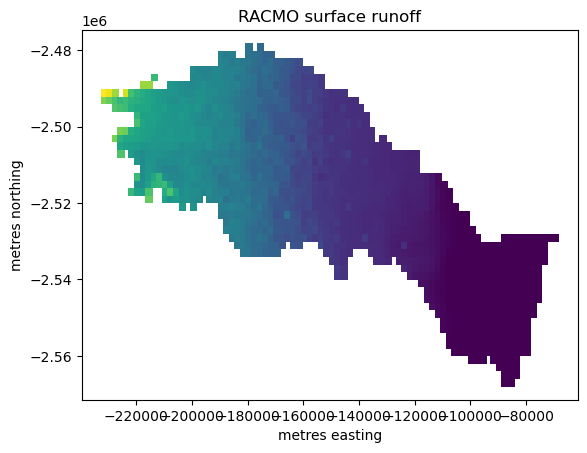

In [ ]:
locs = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/2014_Aug_centroid_clean_half.csv",
    header=None,
).to_numpy()
vals = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/2014_Aug_runoff_clean_half.csv",
    header=None,
).to_numpy()
fig, ax = plt.subplots(1, 1)
# fig.set_size_inches(5,3)
# ax.set_xlim(xlim[0],xlim[1])
# ax.set_ylim(ylim[0],ylim[1])
ax.set_xlabel("metres easting")
ax.set_ylabel("metres northing")
ax.set_title("RACMO surface runoff")
ax.scatter(locs[:, 0], locs[:, 1], c=vals, marker="s", linewidths=0, s=30)

### Discharge data

Daily discharge data is available for the Tasersiaq basin from mid-2015 to 2020, and for the Watson basin from 2006 to 2025. Tasersiaq feeds sites assessed for high hydropower potential, while Watson has a longer observational record.

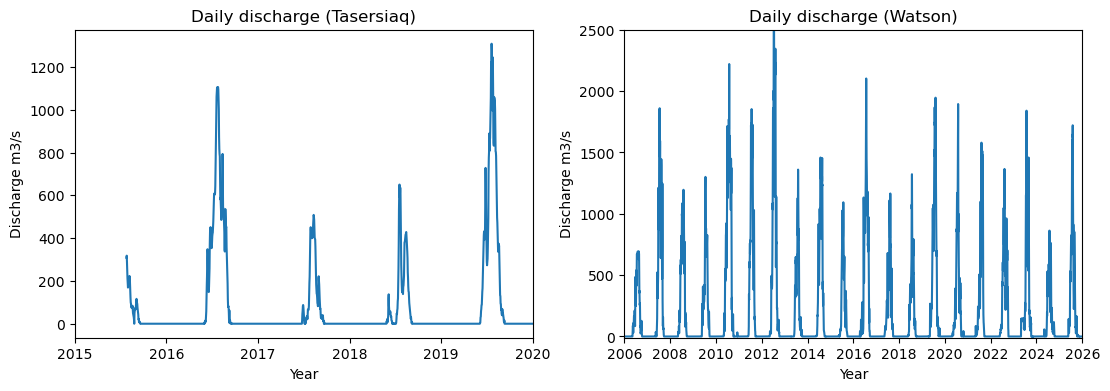

In [ ]:
discharge = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/Basin7e_icesheet_runoff.csv",
    usecols=(1,),
).to_numpy()
discharge2 = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/WatsonDischarge2006_2025.csv",
    usecols=(7,),
).to_numpy()
discharge[5:][np.where(discharge[5:] == "Missing")] = "NaN"
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(13, 4)
ax1.set_xlim(2015, 2020)
# ax.set_ylim(ylim[0],ylim[1])
ax1.set_xlabel("Year")
ax1.set_ylabel("Discharge m3/s")
ax1.set_title("Daily discharge (Tasersiaq)")
ax1.plot(2015 + np.arange(np.shape(discharge)[0] - 5) / 365, discharge[5:].astype(float))
ax2.set_xlim(2006, 2026)
ax2.set_ylim(-10, 2500)
ax2.set_xticks(np.arange(2006, 2027, 2))
# ax.set_ylim(ylim[0],ylim[1])
ax2.set_xlabel("Year")
ax2.set_ylabel("Discharge m3/s")
ax2.set_title("Daily discharge (Watson)")
ax2.plot(2006.03 + np.arange(np.shape(discharge2)[0] - 11) / 365, discharge2[11:].astype(float))

Comparison of the ovelapping years of site data (and supporting study) suggests Watson can be used as a proxy for Tasersiaq.

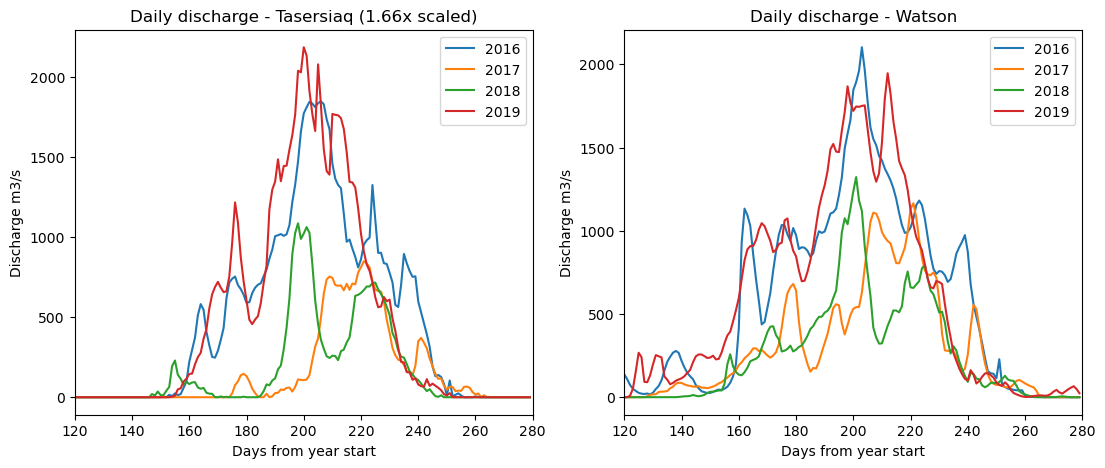

In [ ]:
discharge = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/Basin7e_icesheet_runoff.csv",
    usecols=(1,),
).to_numpy()
discharge2 = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/WatsonDischarge2006_2025.csv",
    usecols=(7,),
).to_numpy()
discharge[5:][np.where(discharge[5:] == "Missing")] = "NaN"
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(13, 5)
ax1.set_xlim(120, 280)
ax1.set_xlabel("Days from year start")
ax1.set_ylabel("Discharge m3/s")
ax1.set_title("Daily discharge - Tasersiaq (1.66x scaled)")
ax1.plot(
    np.arange(120, 280),
    1.67 * discharge[125 + sum(year_days_2015[:1]) : 285 + sum(year_days_2015[:1])].astype(float),
    label="2016",
)
ax1.plot(
    np.arange(120, 280),
    1.67 * discharge[125 + sum(year_days_2015[:2]) : 285 + sum(year_days_2015[:2])].astype(float),
    label="2017",
)
ax1.plot(
    np.arange(120, 280),
    1.67 * discharge[125 + sum(year_days_2015[:3]) : 285 + sum(year_days_2015[:3])].astype(float),
    label="2018",
)
ax1.plot(
    np.arange(120, 280),
    1.67 * discharge[125 + sum(year_days_2015[:4]) : 285 + sum(year_days_2015[:4])].astype(float),
    label="2019",
)
ax1.legend()
ax2.set_xlim(120, 280)
ax2.set_xlabel("Days from year start")
ax2.set_ylabel("Discharge m3/s")
ax2.set_title("Daily discharge - Watson")
ax2.plot(
    np.arange(120, 280),
    discharge2[121 + sum(year_days_2006[:10]) : 281 + sum(year_days_2006[:10])].astype(float),
    label="2016",
)
ax2.plot(
    np.arange(120, 280),
    discharge2[121 + sum(year_days_2006[:11]) : 281 + sum(year_days_2006[:11])].astype(float),
    label="2017",
)
ax2.plot(
    np.arange(120, 280),
    discharge2[121 + sum(year_days_2006[:12]) : 281 + sum(year_days_2006[:12])].astype(float),
    label="2018",
)
ax2.plot(
    np.arange(120, 280),
    discharge2[121 + sum(year_days_2006[:13]) : 281 + sum(year_days_2006[:13])].astype(float),
    label="2019",
)
ax2.legend()

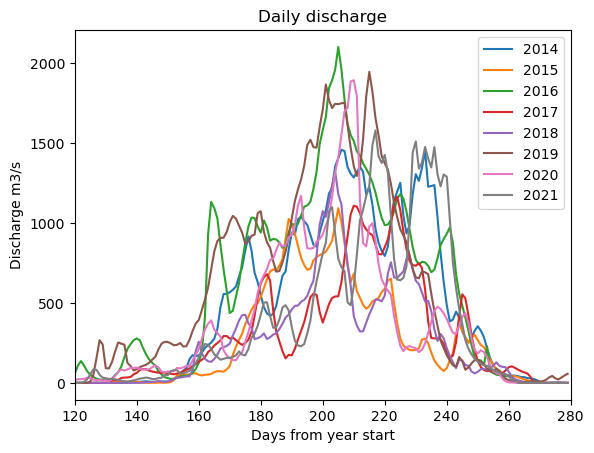

In [ ]:
discharge2 = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/WatsonDischarge2006_2025.csv",
    usecols=(7,),
).to_numpy()
fig, ax = plt.subplots(1, 1)
# fig.set_size_inches(5,3)
ax.set_xlim(120, 280)
# ax.set_ylim(ylim[0],ylim[1])
ax.set_xlabel("Days from year start")
ax.set_ylabel("Discharge m3/s")
ax.set_title("Daily discharge")
for i in np.arange(8, 16):
    ax.plot(np.arange(120, 280), discharge2[121 + 365 * i : 281 + 365 * i].astype(float), label=str(2006 + i))
ax.legend()

## Dataset covariance

Before making the predictive step, pairwise covariance between proglacial discharge and each of the other input datasets is calculated. This informs us how well the variability in proglacial discharge can be explained by each of the input datasets and validates (or invalidates) the user’s choice of model dependencies. Pairwise covariance between each of the input datasets is also calculated - it may not be sensible to include highly correlated datasets in the model and this will help the user to determine that.

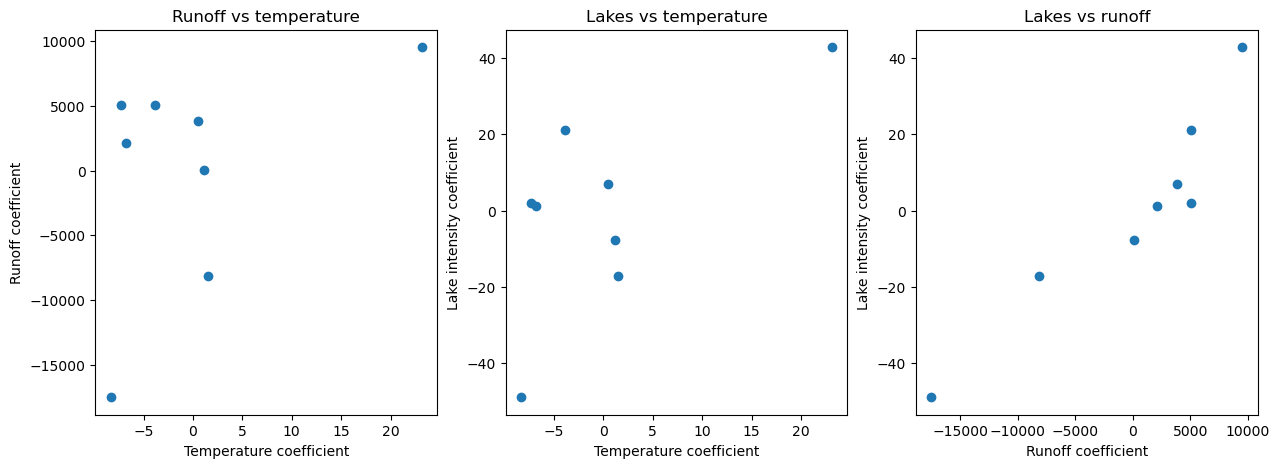

In [ ]:
lake_coeffs = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/lake_coeffs.csv"
).to_numpy()
temp_coeffs = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/temp_coeffs.csv"
).to_numpy()
runoff_coeffs = pd.read_csv(
    "https://dtc-query-api-bucket.s3.gra.io.cloud.ovh.net/use_case_1/notebook_data/runoff_coeffs.csv"
).to_numpy()
m, b = np.polyfit(lake_coeffs[:, 0], runoff_coeffs[:, 0], 1)

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
ax[0].set_xlabel("Temperature coefficient")
ax[0].set_ylabel("Runoff coefficient")
ax[0].set_title("Runoff vs temperature")
ax[0].scatter(temp_coeffs[:, 0], runoff_coeffs[:, 0])
ax[1].set_xlabel("Temperature coefficient")
ax[1].set_ylabel("Lake intensity coefficient")
ax[1].set_title("Lakes vs temperature")
ax[1].scatter(temp_coeffs[:, 0], lake_coeffs[:, 0])
ax[2].set_xlabel("Runoff coefficient")
ax[2].set_ylabel("Lake intensity coefficient")
ax[2].set_title("Lakes vs runoff")
ax[2].scatter(runoff_coeffs[:, 0], lake_coeffs[:, 0])

[78222 43864 94172 49501 43605 95362 61533 62966]
-103.66284846335816
0.4353272100758149
-0.42282385472115447


C:\Users\david\AppData\Local\Temp\ipykernel_32164\2218851226.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Watson_annual[i] = sum(discharge2[131+sum(year_days_2006[:i+8]):281+sum(year_days_2006[:i+8])])


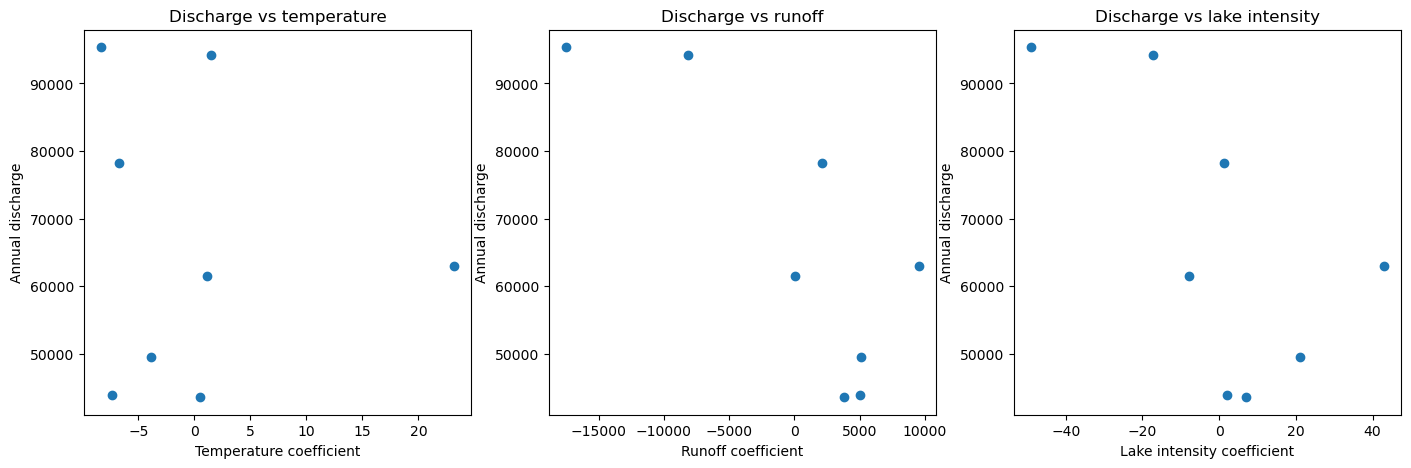

In [36]:
# Covariance between input datasets and observed total discharge

Watson_annual = np.arange(8)
for i in np.arange(8):
    Watson_annual[i] = sum(discharge2[131 + sum(year_days_2006[: i + 8]) : 281 + sum(year_days_2006[: i + 8])])
print(Watson_annual)

m1, b1 = np.polyfit(temp_coeffs[:, 0], Watson_annual, 1)
aa = r2_score(b1 + m1 * temp_coeffs[:, 0], Watson_annual)
print(aa)
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(17, 5)
ax[0].set_xlabel("Temperature coefficient")
ax[0].set_ylabel("Annual discharge")
ax[0].set_title("Discharge vs temperature")
ax[0].scatter(temp_coeffs[:, 0], Watson_annual)

m2, b2 = np.polyfit(runoff_coeffs[:, 0], Watson_annual, 1)
aa = r2_score(b2 + m2 * runoff_coeffs[:, 0], Watson_annual)
print(aa)
ax[1].set_xlabel("Runoff coefficient")
ax[1].set_ylabel("Annual discharge")
ax[1].set_title("Discharge vs runoff")
ax[1].scatter(runoff_coeffs[:, 0], Watson_annual)

m3, b3 = np.polyfit(lake_coeffs[:, 0], Watson_annual, 1)
aa = r2_score(b3 + m3 * lake_coeffs[:, 0], Watson_annual)
print(aa)
ax[2].set_xlabel("Lake intensity coefficient")
ax[2].set_ylabel("Annual discharge")
ax[2].set_title("Discharge vs lake intensity")
ax[2].scatter(lake_coeffs[:, 0], Watson_annual)

## Predicting discharge

### Weekly discharge - validation

Leave one year out of the training dataset and run this cell and the cell below to see how altering the training dataset affects the accuracy of the model.

**USER INPUT** - provide a value for *leave_out* between 2014 and 2021 inclusive to select which year is left out of training

In [ ]:
# User input
leave_out = 2019

week_values = np.zeros(16 * 8)
week_values = week_values.reshape(16, 8)
# We predict for May to September inclusive
week_boundaries = np.arange(143, 260, 7)
for i in np.arange(16):
    for j in np.arange(8):
        week_values[i, j] = sum(
            discharge2[week_boundaries[i] + ((j + 8) * 365) : week_boundaries[i + 1] + ((j + 8) * 365)].astype(float)
        )[0]
weekly_m = np.zeros(16)
weekly_b = np.zeros(16)
for i in np.arange(16):
    weekly_m[i], weekly_b[i] = np.polyfit(
        runoff_coeffs[np.concatenate([np.arange(leave_out - 2014), np.arange(leave_out - 2013, 8)]), 0],
        week_values[i, np.concatenate([np.arange(leave_out - 2014), np.arange(leave_out - 2013, 8)])],
        1,
    )
    aa = r2_score(
        weekly_b[i]
        + weekly_m[i] * runoff_coeffs[np.concatenate([np.arange(leave_out - 2014), np.arange(leave_out - 2013, 8)]), 0],
        week_values[i, np.concatenate([np.arange(leave_out - 2014), np.arange(leave_out - 2013, 8)])],
    )
    print(aa)

0.06445508432849523
-27.20691077729834
-9.50599534591574
0.7588761426157697
-0.30612603445143316
0.629886902648205
-0.3047562325069919
0.5077656188112563
0.5060022255213525
0.6265991950752121
-12.01806559613407
-85.85469003089736
-151.81539680107576
-74.18912527769976
-8.980194011280615
-22.497574901033577


**USER INPUT** - provide a value for year_prediction to select which year to model

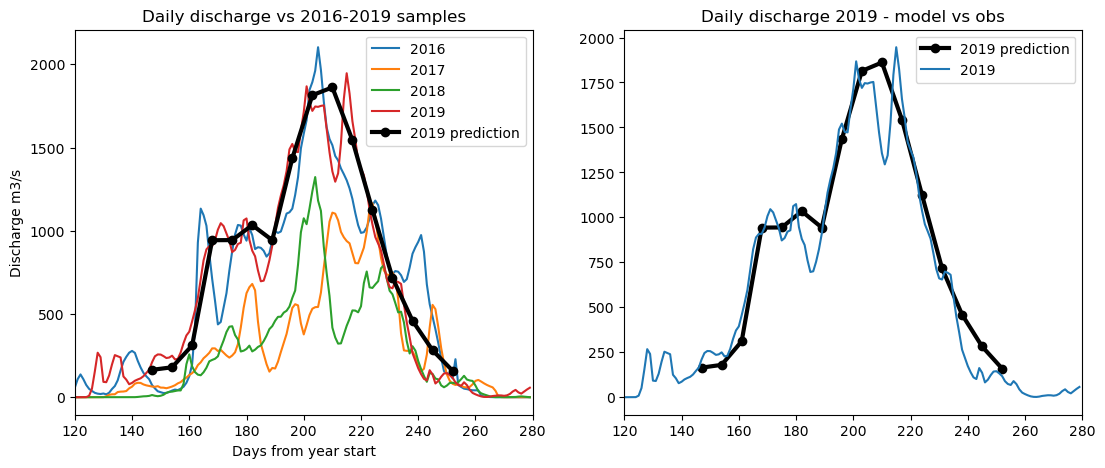

In [ ]:
# User input
year_prediction = 2019

fig, ax = plt.subplots(1, 2)
fig.set_size_inches(13, 5)
ax[0].set_xlim(120, 280)
ax[1].set_xlim(120, 280)
ax[0].set_xlabel("Days from year start")
ax[0].set_ylabel("Discharge m3/s")
ax[0].set_title("Daily discharge vs 2016-2019 samples")
ax[0].plot(np.arange(120, 280), discharge2[121 + 365 * 10 : 281 + 365 * 10].astype(float), label="2016")
ax[0].plot(np.arange(120, 280), discharge2[121 + 365 * 11 : 281 + 365 * 11].astype(float), label="2017")
ax[0].plot(np.arange(120, 280), discharge2[121 + 365 * 12 : 281 + 365 * 12].astype(float), label="2018")
ax[0].plot(np.arange(120, 280), discharge2[121 + 365 * 13 : 281 + 365 * 13].astype(float), label="2019")
ax[0].plot(
    np.arange(147, 255, 7),
    (weekly_b + weekly_m * runoff_coeffs[year_prediction - 2014, 0]) / 7,
    linewidth=3,
    color="k",
    marker="o",
    label=str(year_prediction) + " prediction",
)
ax[0].legend()
ax[1].set_title("Daily discharge " + str(year_prediction) + " - model vs obs")
ax[0].set_xlabel("Days from year start")
ax[1].plot(
    np.arange(147, 255, 7),
    (weekly_b + weekly_m * runoff_coeffs[year_prediction - 2014, 0]) / 7,
    linewidth=3,
    color="k",
    marker="o",
    label=str(year_prediction) + " prediction",
)
ax[1].plot(
    np.arange(120, 280),
    discharge2[121 + 365 * (year_prediction - 2006) : 281 + 365 * (year_prediction - 2006)].astype(float),
    label=str(year_prediction),
)
ax[1].legend()

### Weekly discharge - alternative climate scenario

This section generates a 20 year synthetic timeseries of runoff coefficients according to a given set of parameters, then models runoff based on these years and displays the range and mean of the resulting weekly discharge compared to the range and mean within the training data.

**USER INPUT** - Set *runoff_weight* to a value between 0 and 1 - 0 for extreme weighting towards low runoff coefficients, 1 for extreme weighting towards high runoff coefficients, 0.5 for centre

**USER INPUT** - Set *runoff_variability* to a value between 0 and 2 - 0 for no variability in the prediction range, 1 for the same variability as in the input data, 2 for twice the variability

*Note that results are not necessarily robust with very strong weighting and high variability as this can push climate far outside the training range*

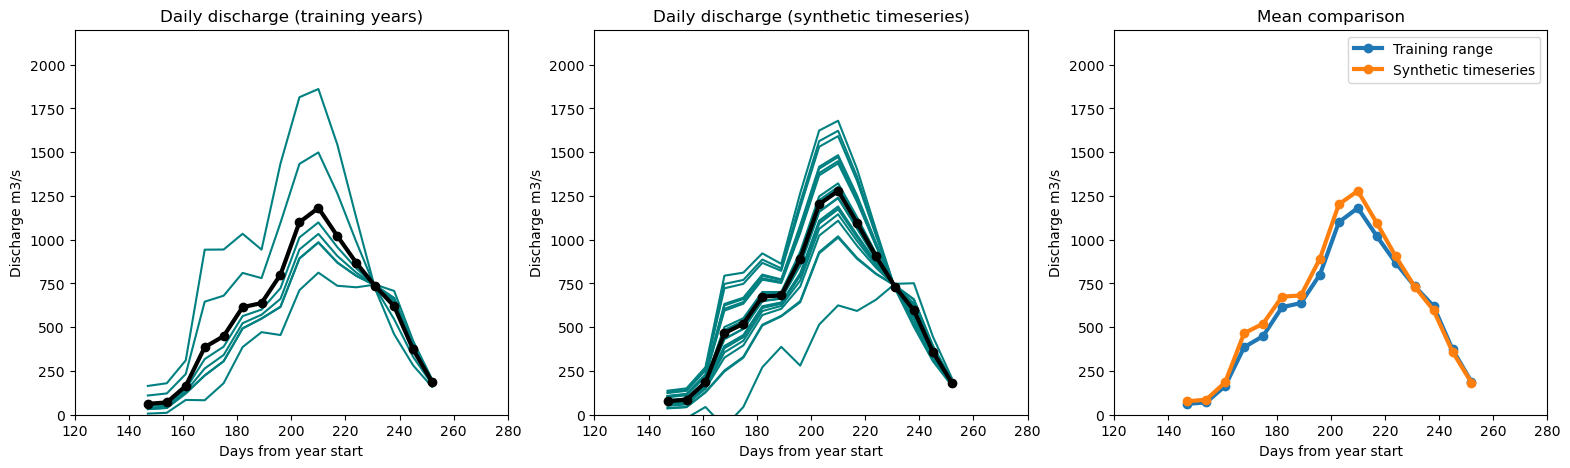

In [ ]:
# User input

runoff_weight = 0.5  # 0.5 default, 0 min, 1 max
runoff_variability = 1  # 1 default, 0 min, 2 max

week_values = np.zeros(16 * 8)
week_values = week_values.reshape(16, 8)
# We predict for May to September inclusive
week_boundaries = np.arange(143, 260, 7)
for i in np.arange(16):
    for j in np.arange(8):
        week_values[i, j] = sum(
            discharge2[week_boundaries[i] + ((j + 8) * 365) : week_boundaries[i + 1] + ((j + 8) * 365)].astype(float)
        )[0]
weekly_m = np.zeros(16)
weekly_b = np.zeros(16)
for i in np.arange(16):
    weekly_m[i], weekly_b[i] = np.polyfit(runoff_coeffs[:, 0], week_values[i, :], 1)
    aa = r2_score(weekly_b[i] + weekly_m[i] * runoff_coeffs[:, 0], week_values[i, :])

fig, ax = plt.subplots(1, 3)
fig.set_size_inches(19, 5)
obs_matrix = np.zeros(16 * 8)
obs_matrix = obs_matrix.reshape(16, 8)
ax[0].set_xlim(120, 280)
ax[0].set_ylim(0, 2200)
ax[0].set_xlabel("Days from year start")
ax[0].set_ylabel("Discharge m3/s")
ax[0].set_title("Daily discharge (training years)")
for i in np.arange(8):
    obs_matrix[:, i] = (weekly_b + weekly_m * runoff_coeffs[i, 0]) / 7
    ax[0].plot(np.arange(147, 255, 7), obs_matrix[:, i], color="teal")
ax[0].plot(
    np.arange(147, 255, 7),
    np.mean(obs_matrix, 1),
    linewidth=3,
    color="k",
    marker="o",
    label=str(year_prediction) + " prediction",
)

sample_size = 20
sample_seed = np.random.normal(
    ((0.5 - runoff_weight) * 2) * np.std(runoff_coeffs[:, 0]),
    np.std(runoff_coeffs[:, 0]) * runoff_variability,
    sample_size,
)
sample_matrix = np.zeros(16 * sample_size)
sample_matrix = sample_matrix.reshape(16, sample_size)
ax[1].set_xlim(120, 280)
ax[1].set_ylim(0, 2200)
ax[1].set_xlabel("Days from year start")
ax[1].set_ylabel("Discharge m3/s")
ax[1].set_title("Daily discharge (synthetic timeseries)")
for i in np.arange(sample_size):
    sample_matrix[:, i] = (weekly_b + weekly_m * sample_seed[i]) / 7
    ax[1].plot(np.arange(147, 255, 7), sample_matrix[:, i], color="teal")
ax[1].plot(
    np.arange(147, 255, 7),
    np.mean(sample_matrix, 1),
    linewidth=3,
    color="k",
    marker="o",
    label=str(year_prediction) + " prediction",
)

ax[2].set_xlim(120, 280)
ax[2].set_ylim(0, 2200)
ax[2].set_xlabel("Days from year start")
ax[2].set_ylabel("Discharge m3/s")
ax[2].set_title("Mean comparison")
ax[2].plot(np.arange(147, 255, 7), np.mean(obs_matrix, 1), linewidth=3, marker="o", label="Training range")
ax[2].plot(np.arange(147, 255, 7), np.mean(sample_matrix, 1), linewidth=3, marker="o", label="Synthetic timeseries")
ax[2].legend()

## Conclusions

Thank you for exploring this DTC-IS demonstrator notebook. We hope it's given you a useful introduction to hydropower planning using predicted freshwater flux from the Greenland ice sheet, and to working with the DTC-IS framework - feel free to revisit it with different variables and parameters to explore further.

We welcome your feedback, questions, and suggestions for new features. You can reach the DTC-IS team at support@dtc-ice-sheets.org.